# **Generazione e riconoscimento di tonalità DTMF**

**Import cell**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
from scipy.fft import fft, fftshift, ifft
import os
from src.implementazione_DTMF import (
    tone,
    dialNumber,
    plot_and_save_sequence,
    plot_spectrum,
    recNumber,
    recSequence,
    dialNumber_pauses,
    detect_sequence_pauses,
    save_plot
)

In [ ]:
plots_dir = "Plots"
os.makedirs(plots_dir, exist_ok=True)

## **1. Implementazione DTMF**

### **1.1 Creazione del dizionario**

In [ ]:
# Definizione degli array delle frequenze
F1 = np.array([697, 770, 852, 941])
F2 = np.array([1209, 1336, 1477, 1633]) 

# Definizione del dizionario di toni
tones = {
    '1': (0,0),
    '2': (0,1),
    '3': (0,2),
    '4': (1,0),
    '5': (1,1),
    '6': (1,2),
    '7': (2,0),
    '8': (2,1),
    '9': (2,2),
    '0': (3,1),
    '*': (3,0),
    '#': (3,2),
    'A': (0,3),
    'B': (1,3),
    'C': (2,3),
    'D': (3,3),
    
}
print(tones)

### **1.2 Esempio applicativo**

**Plot dei toni nel dominio del tempo**

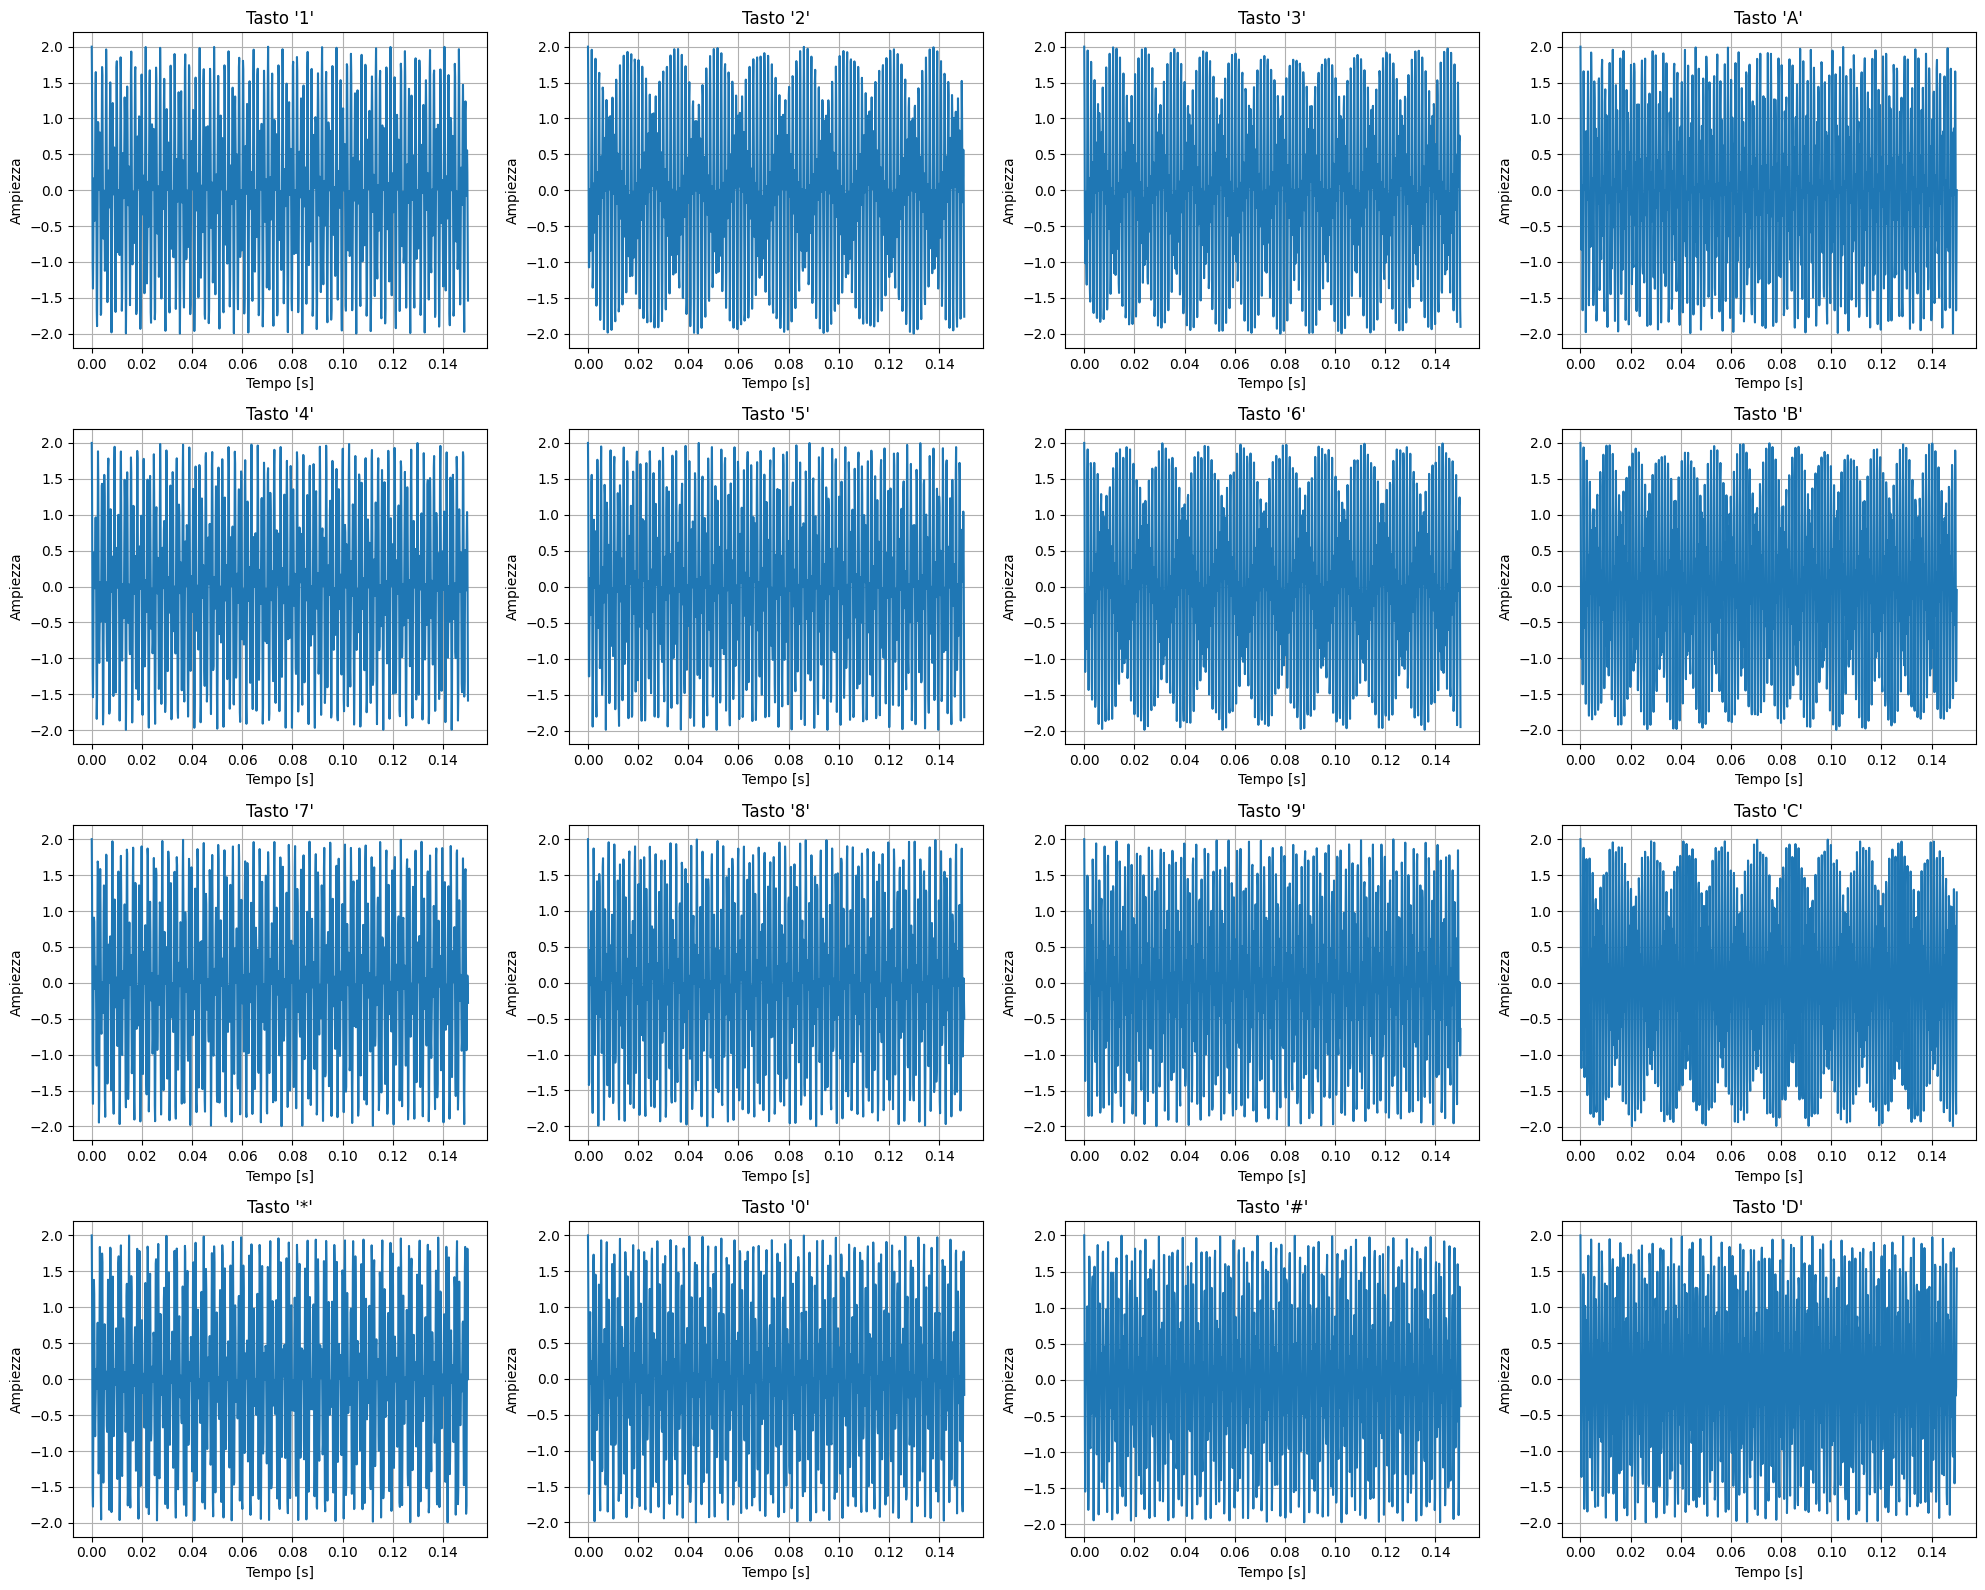

Plot dei segnali nel tempo salvato in: Plots/all_tones/all_tones_time.png


In [ ]:
# Creazione cartella
all_tones_dir = "Plots/all_tones"
os.makedirs(all_tones_dir, exist_ok=True)

# Tastiera
keypad_rows = [
    ['1','2','3','A'],
    ['4','5','6','B'],
    ['7','8','9','C'],
    ['*','0','#','D']
]

# Flatten dei tasti
all_keys = [k for row in keypad_rows for k in row]

# Frequenza di campionamento
Fs = 8000
duration = 0.15

# Plot
fig_time, axes_time = plt.subplots(4, 4, figsize=(20, 16))

for idx, key in enumerate(all_keys):
    
    t, x = tone(key, duration, Fs, F1, F2, tones)

    r = idx // 4
    c = idx % 4
    ax = axes_time[r, c]

    ax.plot(t, x)
    ax.set_title(f"Tasto '{key}'")
    ax.set_xlabel("Tempo [s]")
    ax.set_ylabel("Ampiezza")
    ax.grid(True)
    
plt.tight_layout()

time_plot_path = os.path.join(all_tones_dir, "all_tones_time.png")
fig_time.savefig(time_plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Plot dei segnali nel tempo salvato in:", time_plot_path)

**Plot dei toni nel dominio della frequenza**

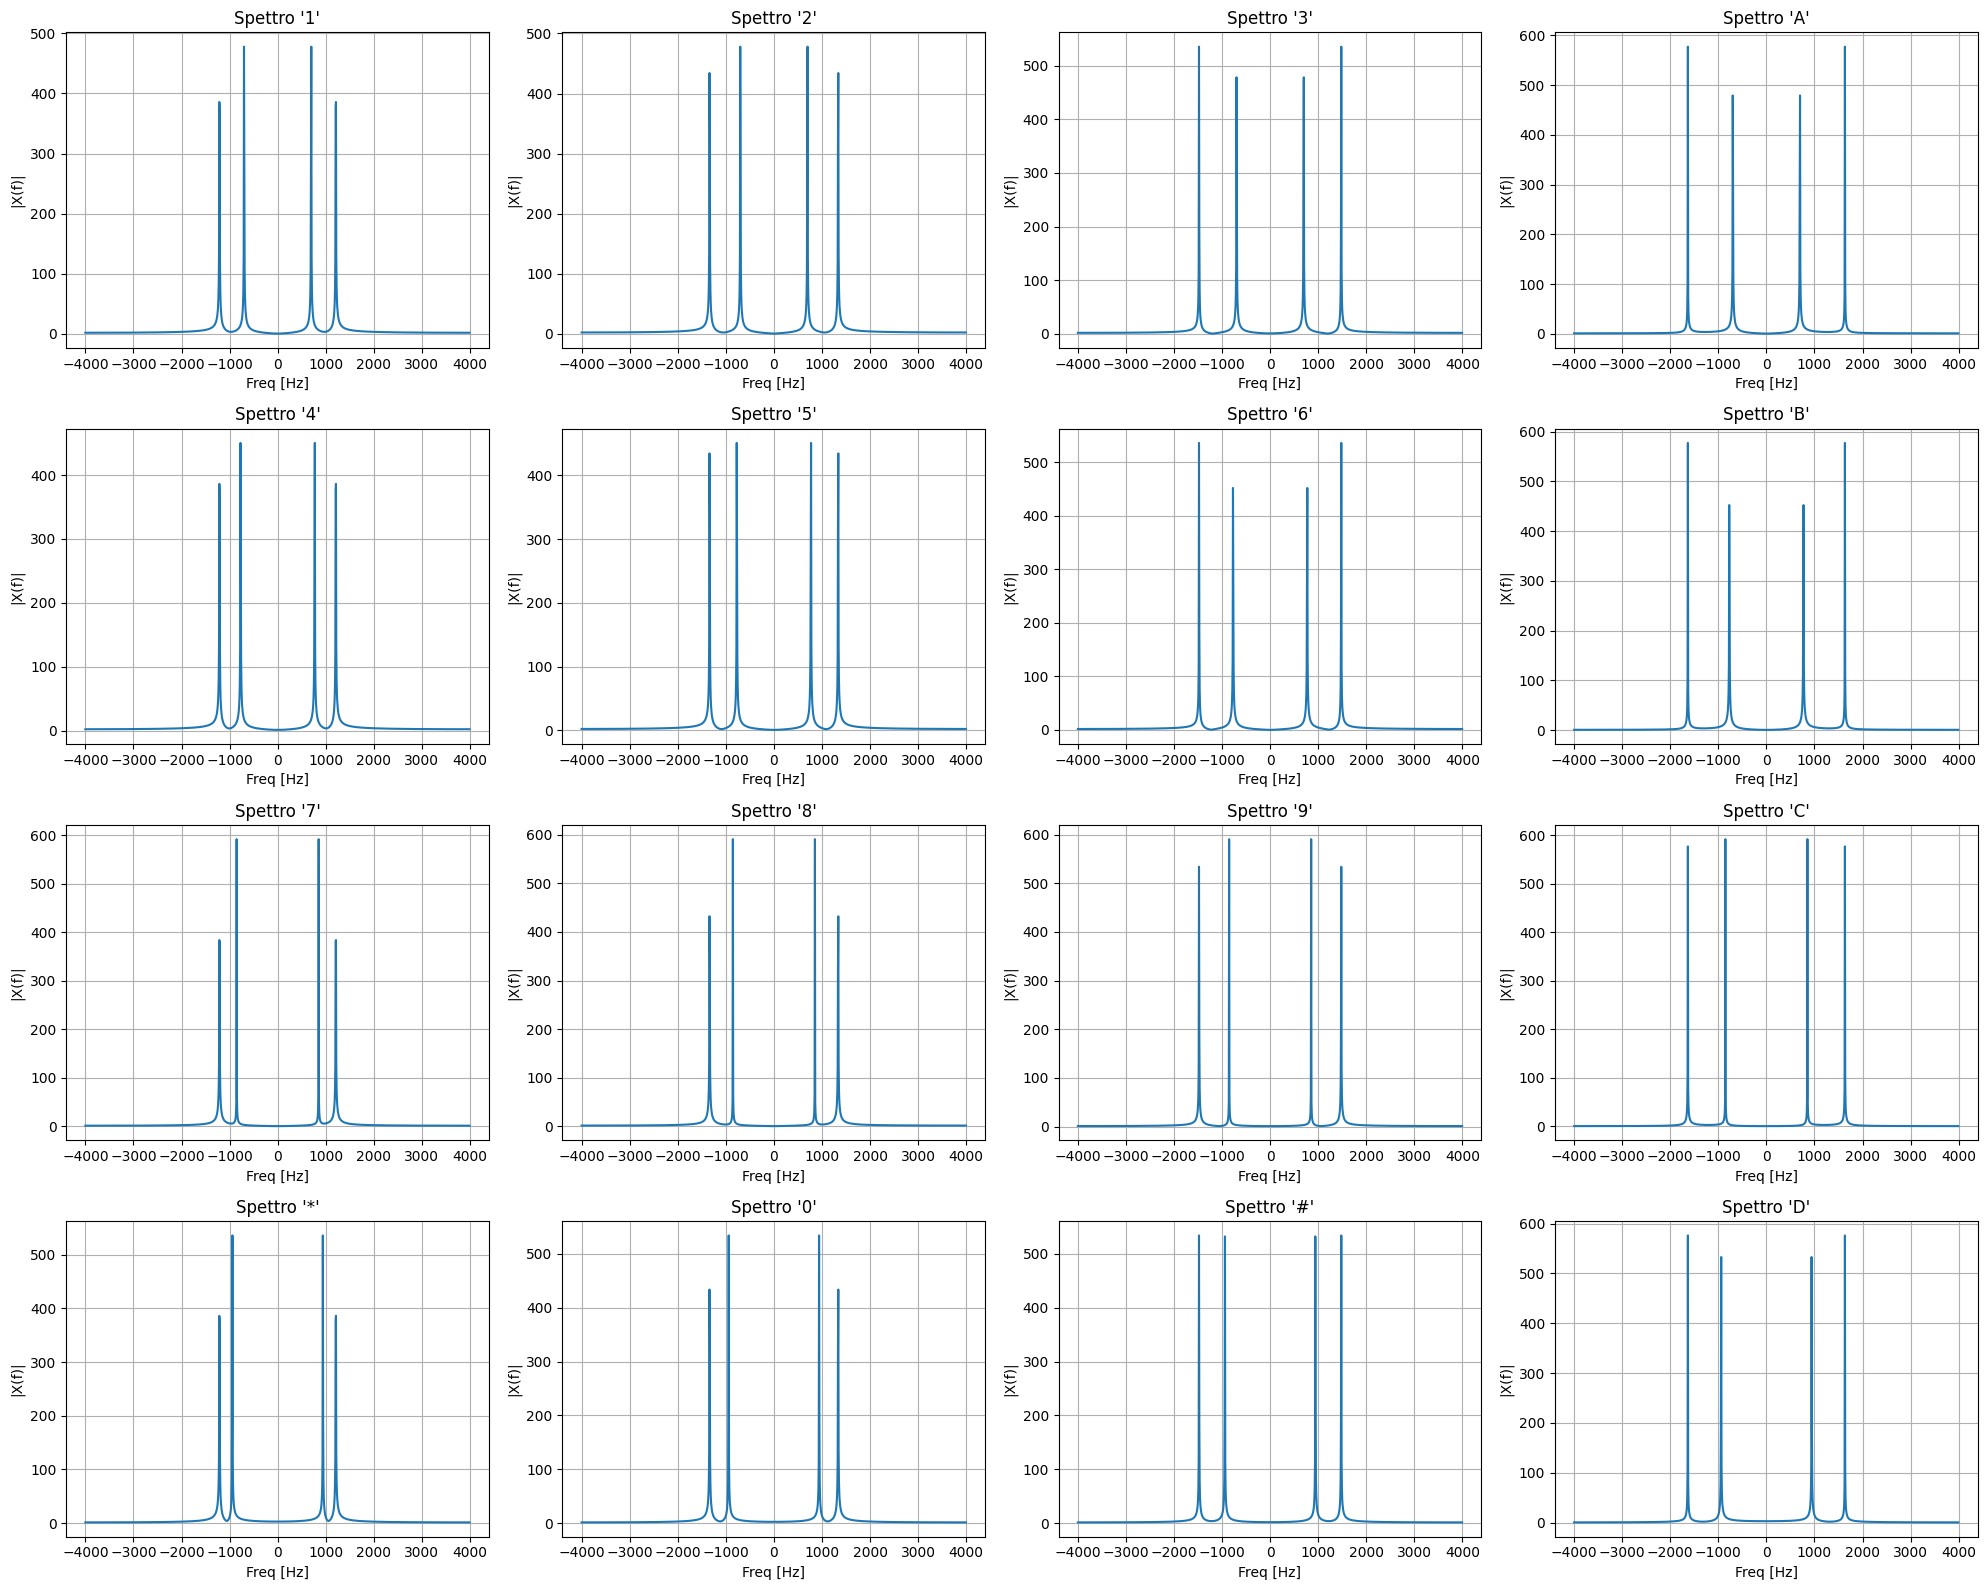

Plot degli spettri salvato in: Plots/all_tones/all_tones_freq.png


In [13]:
# Cartella dove salvare il plot
all_tones_dir = "Plots/all_tones"
os.makedirs(all_tones_dir, exist_ok=True)

fig_freq, axes_freq = plt.subplots(4, 4, figsize=(20, 16))

for r in range(4):
    for c in range(4):
        
        key = keypad_rows[r][c]
        t, x = tone(key, duration, Fs)

        # FFT
        N = len(x)
        X = fft(x)
        X_shifted = fftshift(X)
        freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

        ax = axes_freq[r, c]

        # Spettro (modulo)
        ax.plot(freqs, np.abs(X_shifted))
        ax.set_title(f"Spettro '{key}'")
        ax.set_xlabel("Freq [Hz]")
        ax.set_ylabel("|X(f)|")
        ax.grid(True)

plt.tight_layout()

# Salvataggio
freq_plot_path = os.path.join(all_tones_dir, "all_tones_freq.png")
fig_freq.savefig(freq_plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Plot degli spettri salvato in:", freq_plot_path)

Plot salvato in: Plots/sequenza.png


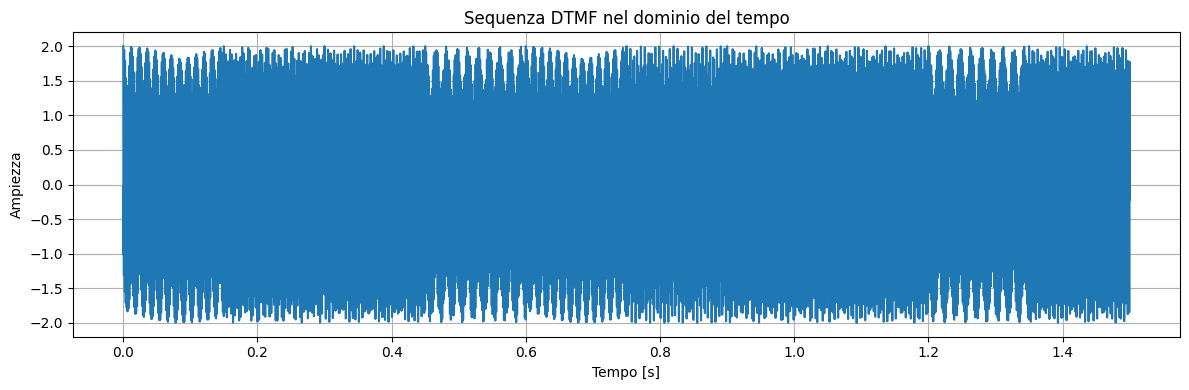

Audio salvato: sequenza.wav
Plot salvato in: Plots/spettro_sequenza.png


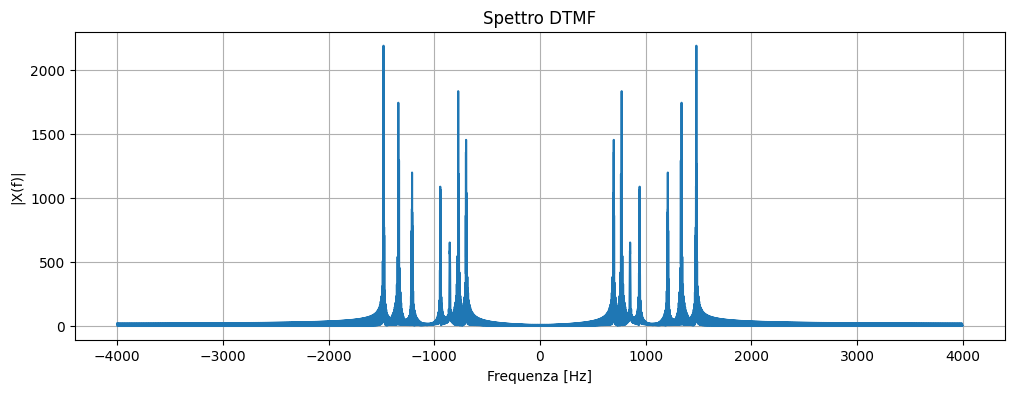

(array([-4000.        , -3999.33333333, -3998.66666667, ...,
         3998.        ,  3998.66666667,  3999.33333333]),
 array([17.50205654-0.j        , -0.43774436-1.24140538j,
         0.0816677 +0.15751167j, ..., -0.41925794-0.93530485j,
         0.0816677 -0.15751167j, -0.43774436+1.24140538j]))

In [14]:
# Generazione e visualizzazione della sequenza '3456318060'
sequenza = "3456318060"
toneDuration = 0.15
full_signal = dialNumber(sequenza, Fs, toneDuration)

plot_and_save_sequence(full_signal, Fs, filename="sequenza.wav", plot_filename="sequenza.png")
# Spettro sequenza
plot_spectrum(full_signal, Fs, plot_filename="spettro_sequenza.png")

In [ ]:
# Riconoscimento della sequenza
detected = recSequence(full_signal, toneDuration=0.15, Fs=8000)
print("Sequenza riconosciuta:", detected)

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


**Inserimento di pause tra un tono e l'altro**

Plot salvato in: Plots/sequenza_pause.png


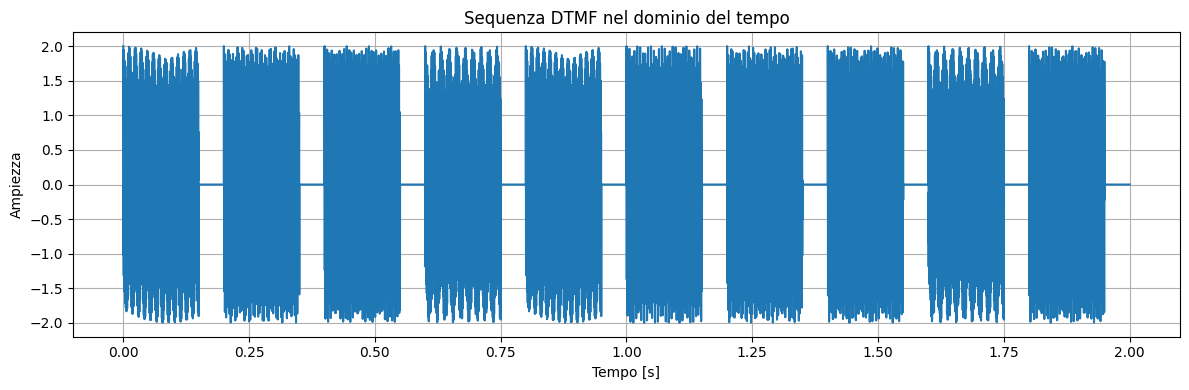

Audio salvato: sequenza_pause.wav
Plot salvato in: Plots/spettro_sequenza_pause.png


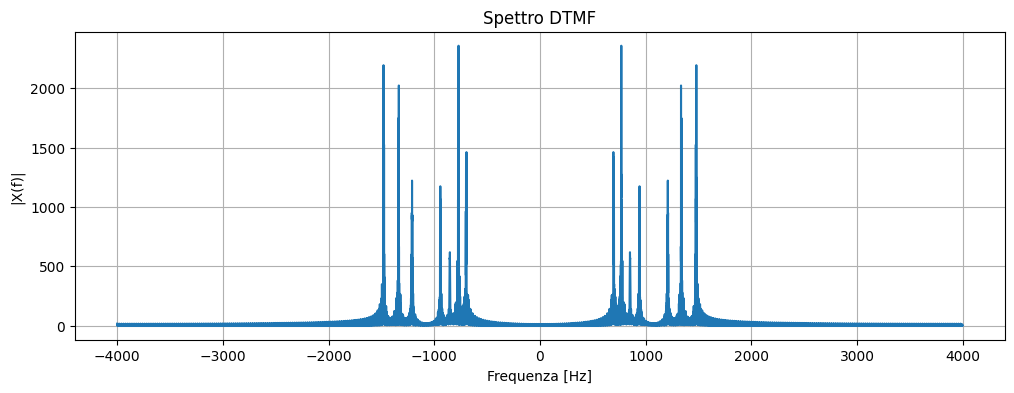

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


In [18]:
full_signal_pauses = dialNumber_pauses(sequenza, Fs, toneDuration, pauseDuration=0.05)

plot_and_save_sequence(full_signal_pauses, Fs, filename="sequenza_pause.wav",
                       plot_filename="sequenza_pause.png")

plot_spectrum(full_signal_pauses, Fs, plot_filename="spettro_sequenza_pause.png")

detected_pauses = detect_sequence_pauses(full_signal_pauses, toneDuration=toneDuration,
                                         pauseDuration=0.05, Fs=Fs, silence_threshold=0.05)

print("Sequenza riconosciuta:", detected_pauses)


Plot salvato in: Plots/spettro_overlay_pause.png


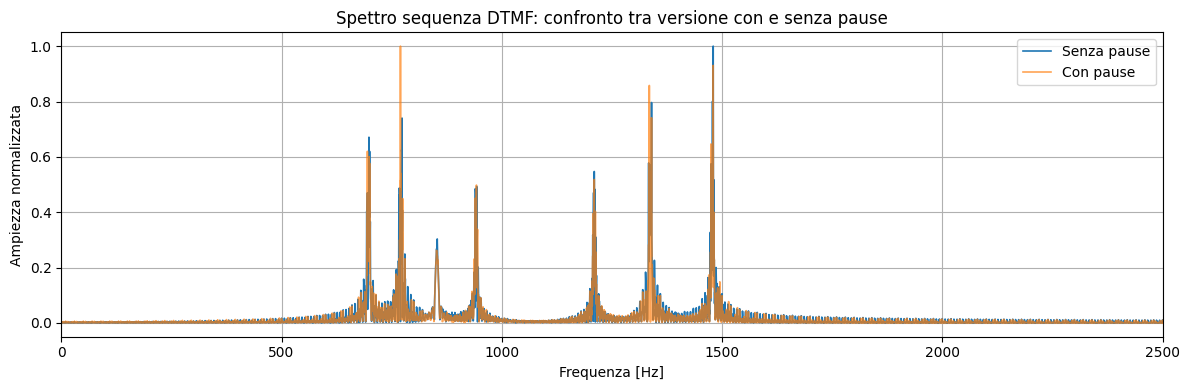

In [19]:
# Lunghezze originali
N_no = len(full_signal)
N_pa = len(full_signal_pauses)

# Lunghezza massima
N = max(N_no, N_pa)

# Padding per allineare le lunghezze
sig_no = np.pad(full_signal, (0, N - N_no), mode='constant')
sig_pa = np.pad(full_signal_pauses, (0, N - N_pa), mode='constant')

# FFT
X_no = fftshift(fft(sig_no))
X_pa = fftshift(fft(sig_pa))

# Ampiezze normalizzate
X_no_norm = np.abs(X_no) / np.max(np.abs(X_no))
X_pa_norm = np.abs(X_pa) / np.max(np.abs(X_pa))

# Asse delle frequenze
freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

# Plot overlay
plt.figure(figsize=(12,4))
plt.plot(freqs, X_no_norm, label="Senza pause", linewidth=1.2)
plt.plot(freqs, X_pa_norm, label="Con pause", alpha=0.7, linewidth=1.2)
plt.xlim(0, 2500)
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Ampiezza normalizzata")
plt.title("Spettro sequenza DTMF: confronto tra versione con e senza pause")
plt.grid(True)
plt.legend()
save_plot("spettro_overlay_pause.png")
plt.show()

## **2. Esperimenti e metodologia**

### **2.1 Variazione della durata del tono**

### **2.2 Aggiunta di rumore al segnale**

In [20]:
def save_plot_subfolder(folder, filename):
    """
    Salva il plot nella cartella indicata, creandola se non esiste.
    """
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Plot salvato in: {path}")

Figura salvata in: Plots_noise/noise_time_freq.png


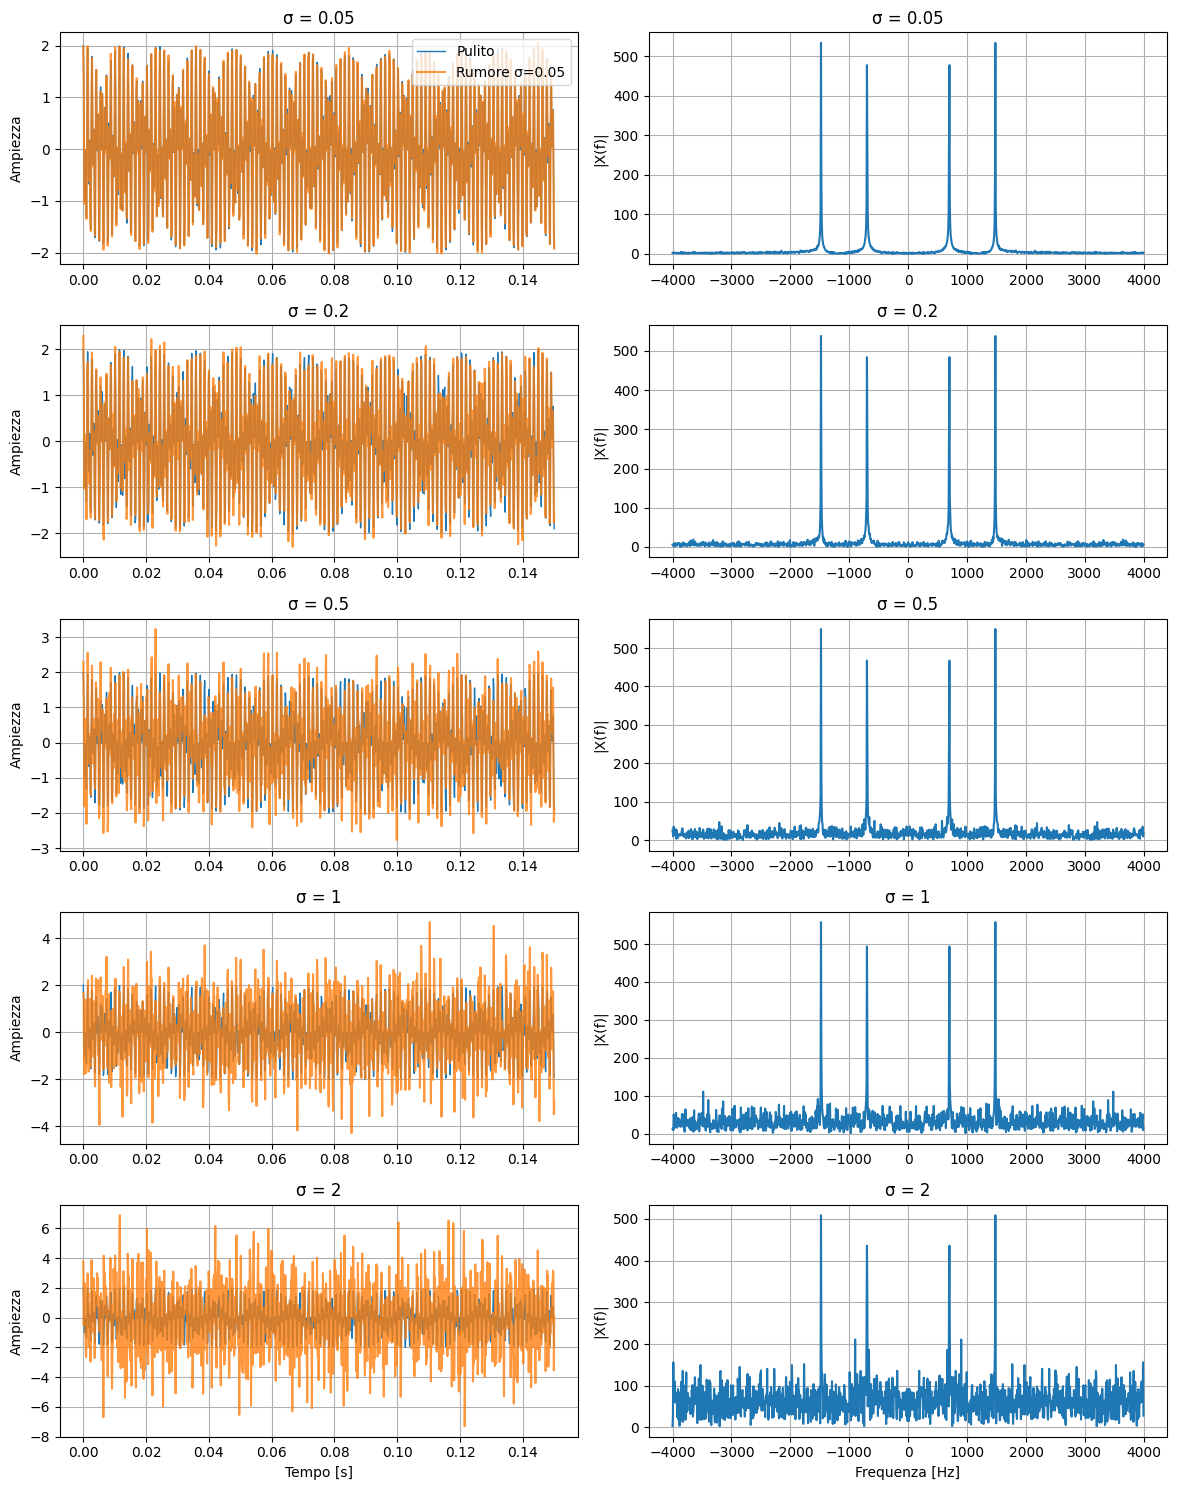

In [23]:
# Cartella per i plot del rumore
noise_dir = "Plots_noise"
os.makedirs(noise_dir, exist_ok=True)

Fs = 8000
tone_char = '3'
duration = 0.15

# Tono pulito
t_clean, x_clean = tone(tone_char, duration, Fs)

# Livelli di rumore
sigmas = [0.05, 0.2, 0.5, 1, 2]
n_sigmas = len(sigmas)

fig, axes = plt.subplots(n_sigmas, 2, figsize=(12, 3 * n_sigmas), sharex=False)
axes = np.atleast_2d(axes)

for idx, sigma in enumerate(sigmas):
    # Genero rumore e segnale rumoroso
    noise = np.random.normal(0, sigma, len(x_clean))
    x_noisy = x_clean + noise

    # Dominio del tempo
    ax_time = axes[idx, 0]
    ax_time.plot(t_clean, x_clean, label="Pulito", linewidth=1)
    ax_time.plot(t_clean, x_noisy, label=f"Rumore σ={sigma}", alpha=0.8)
    ax_time.set_title(f"σ = {sigma}")
    ax_time.set_ylabel("Ampiezza")
    ax_time.grid(True)
    if idx == n_sigmas - 1:
        ax_time.set_xlabel("Tempo [s]")
    if idx == 0:
        ax_time.legend(loc="upper right")

    # Dominio della frequenza
    N = len(x_noisy)
    X = fft(x_noisy)
    X_shifted = fftshift(X)
    freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

    ax_freq = axes[idx, 1]
    ax_freq.plot(freqs, np.abs(X_shifted))
    ax_freq.set_title(f"σ = {sigma}")
    ax_freq.set_ylabel("|X(f)|")
    ax_freq.grid(True)
    if idx == n_sigmas - 1:
        ax_freq.set_xlabel("Frequenza [Hz]")

plt.tight_layout()

# Salvataggio della figura completa
noise_grid_path = os.path.join(noise_dir, "noise_time_freq.png")
plt.savefig(noise_grid_path, dpi=300, bbox_inches="tight")
print(f"Figura salvata in: {noise_grid_path}")
plt.show()
plt.close()

Plot salvato in: Plots_noise/rumore_progressivo_zoom.png


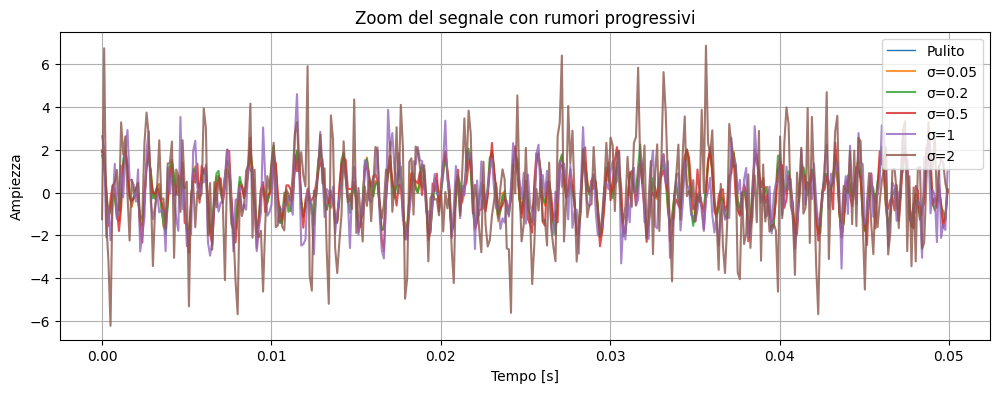

In [24]:
t_zoom = t_clean[:400] # primi 400 campioni ≈ 5 ms
x_clean_zoom = x_clean[:400]

plt.figure(figsize=(12,4))
plt.plot(t_zoom, x_clean_zoom, label="Pulito", linewidth=1)

for sigma in sigmas:
    x_noisy_zoom = x_clean[:400] + np.random.normal(0, sigma, 400)
    plt.plot(t_zoom, x_noisy_zoom, label=f"σ={sigma}", alpha=0.8)

plt.title("Zoom del segnale con rumori progressivi")
plt.xlabel("Tempo [s]")
plt.ylabel("Ampiezza")
plt.grid(True)
plt.legend()

save_plot_subfolder(noise_dir, "rumore_progressivo_zoom.png")
plt.show()
plt.close()

### **2.3 Variazione della frequenza di campionamento**

## **3. Miglioramenti dell'algoritmo**

### **3.1 Zero-padding**

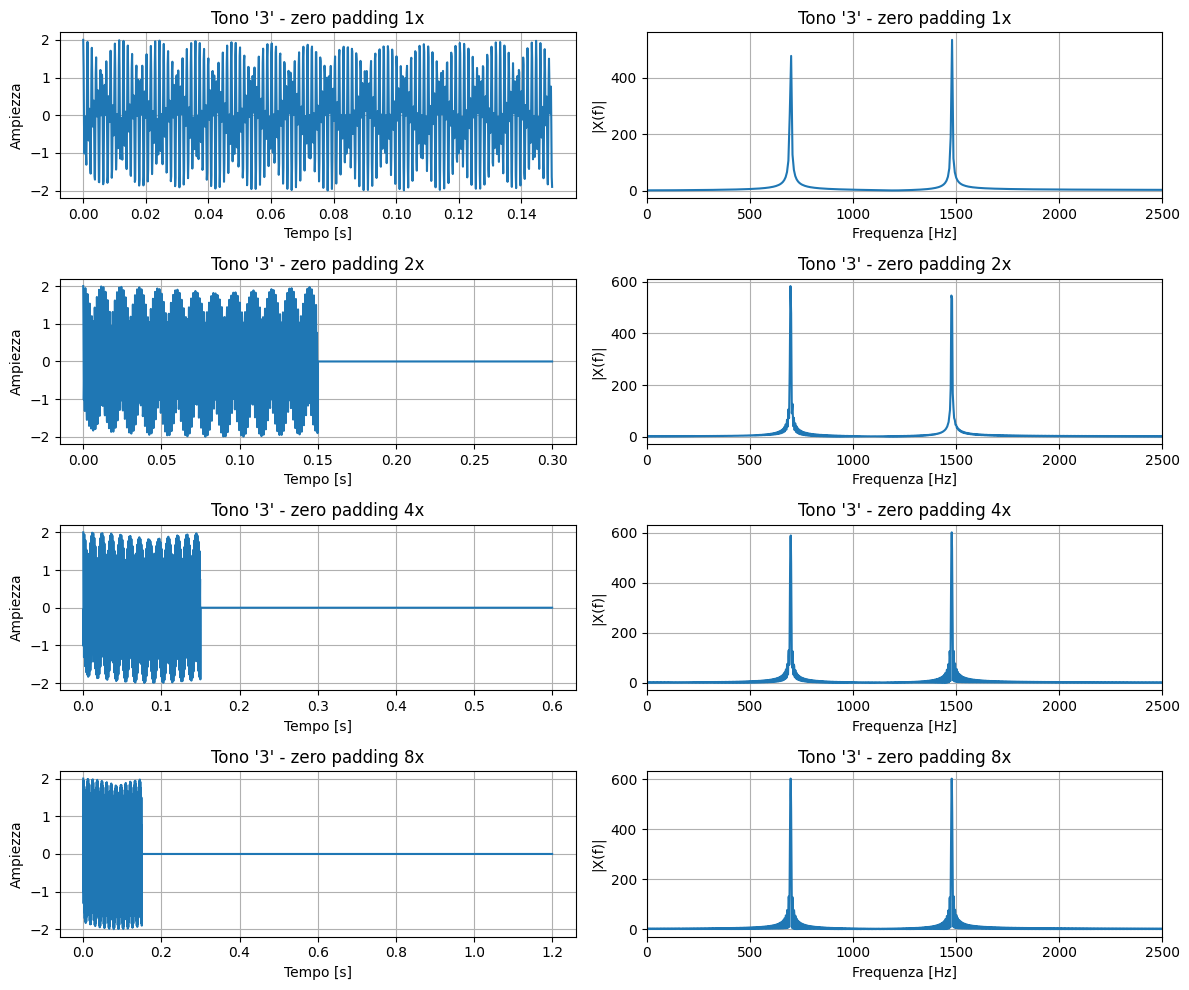

Figura zero-padding salvata in: Plots_zero_padding/zero_padding_time_freq.png


In [22]:
Fs = 8000
duration = 0.15
tone_char = '3'

# Genero tono base
t, x = tone(tone_char, duration, Fs)

# Lunghezza originale
N = len(x)

# Fattori di padding
padding_factors = [1, 2, 4, 8]

# Cartella
base_folder = "Plots_zero_padding"
os.makedirs(base_folder, exist_ok=True)

# Plot
fig, axes = plt.subplots(len(padding_factors), 2,
                         figsize=(12, 10),
                         sharex=False)

for row, factor in enumerate(padding_factors):

    # Lunghezza dopo zero padding
    N_pad = N * factor
    
    # Zero padding
    x_padded = np.pad(x, (0, N_pad - N), mode='constant')

    # Asse dei tempi per il segnale padded
    t_padded = np.arange(N_pad) / Fs
    
    # FFT e asse delle frequenze
    X = fft(x_padded)
    X_shifted = fftshift(X)
    freqs = np.linspace(-Fs/2, Fs/2, N_pad, endpoint=False)

    # Plot dominio del tempo
    ax_time = axes[row, 0]
    ax_time.plot(t_padded, x_padded)
    ax_time.set_title(f"Tono '{tone_char}' - zero padding {factor}x")
    ax_time.set_xlabel("Tempo [s]")
    ax_time.set_ylabel("Ampiezza")
    ax_time.grid(True)

    # Plot dominio della frequenza
    ax_freq = axes[row, 1]
    ax_freq.plot(freqs, np.abs(X_shifted))
    ax_freq.set_title(f"Tono '{tone_char}' - zero padding {factor}x")
    ax_freq.set_xlabel("Frequenza [Hz]")
    ax_freq.set_ylabel("|X(f)|")
    ax_freq.grid(True)
    ax_freq.set_xlim(0, 2500)

plt.tight_layout()

# Salvataggio figura
out_path = os.path.join(base_folder, "zero_padding_time_freq.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura zero-padding salvata in:", out_path)


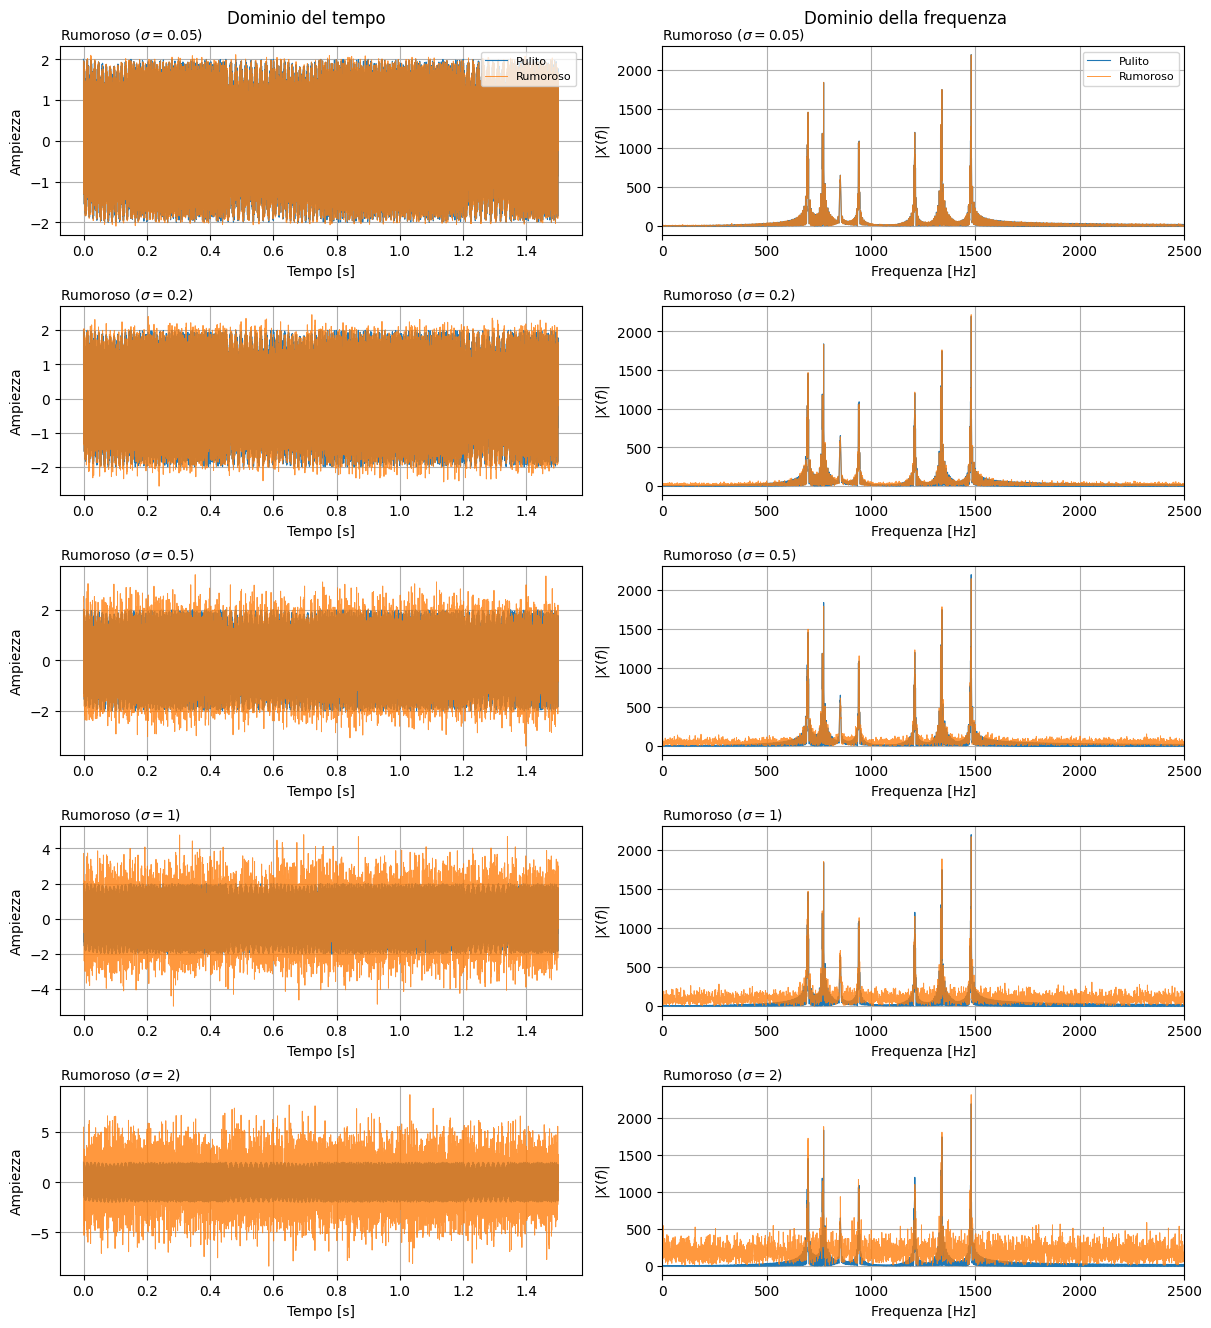

Figura salvata in: Plots_noise/noise_time_freq_sequence.png


In [25]:
noise_seq_dir = "Plots_noise"
os.makedirs(noise_seq_dir, exist_ok=True)

Fs = 8000
duration = 0.15
sequenza = "3456318060"

# Segnale pulito
x_clean = dialNumber(sequenza, Fs, duration)
t_clean = np.linspace(0, len(x_clean)/Fs, len(x_clean))

# Livelli di rumore
sigmas = [0.05, 0.2, 0.5, 1, 2]
n_rows = len(sigmas)

fig, axes = plt.subplots(
    n_rows, 2,
    figsize=(12, 2.6 * n_rows),
    constrained_layout=True
)

# FFT del segnale pulito
X_clean = fftshift(fft(x_clean))
freqs = np.linspace(-Fs/2, Fs/2, len(X_clean), endpoint=False)

for row, sigma in enumerate(sigmas):

    noise = np.random.normal(0, sigma, len(x_clean))
    x_noisy = x_clean + noise
    label_row = rf"Rumoroso ($\sigma = {sigma}$)"

    # Dominio del tempo
    ax_time = axes[row, 0]
    ax_time.plot(t_clean, x_clean, linewidth=0.8, label="Pulito")
    ax_time.plot(t_clean, x_noisy, linewidth=0.7, alpha=0.8, label="Rumoroso")
    ax_time.grid(True)
    ax_time.set_xlabel("Tempo [s]")
    ax_time.set_ylabel("Ampiezza")
    ax_time.annotate(
        label_row,
        xy=(0.0, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom"
    )

    if row == 0:
        ax_time.legend(loc="upper right", fontsize=8)

    # Dominio della frequenza
    X_noisy = fftshift(fft(x_noisy))

    ax_freq = axes[row, 1]
    ax_freq.plot(freqs, np.abs(X_clean), linewidth=0.8, label="Pulito")
    ax_freq.plot(freqs, np.abs(X_noisy), linewidth=0.7, alpha=0.8, label="Rumoroso")
    ax_freq.grid(True)
    ax_freq.set_xlim(0, 2500)
    ax_freq.set_xlabel("Frequenza [Hz]")
    ax_freq.set_ylabel(r"$|X(f)|$")

    ax_freq.annotate(
        label_row,
        xy=(0.0, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom"
    )

    if row == 0:
        ax_freq.legend(loc="upper right", fontsize=8)

fig.text(0.25, 1.01, "Dominio del tempo", ha="center", va="top", fontsize=12)
fig.text(0.75, 1.01, "Dominio della frequenza", ha="center", va="top", fontsize=12)

fig_path = os.path.join(noise_seq_dir, "noise_time_freq_sequence.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura salvata in:", fig_path)

Plot salvato in: Plots_noise/sovrapposizione_rumori.png


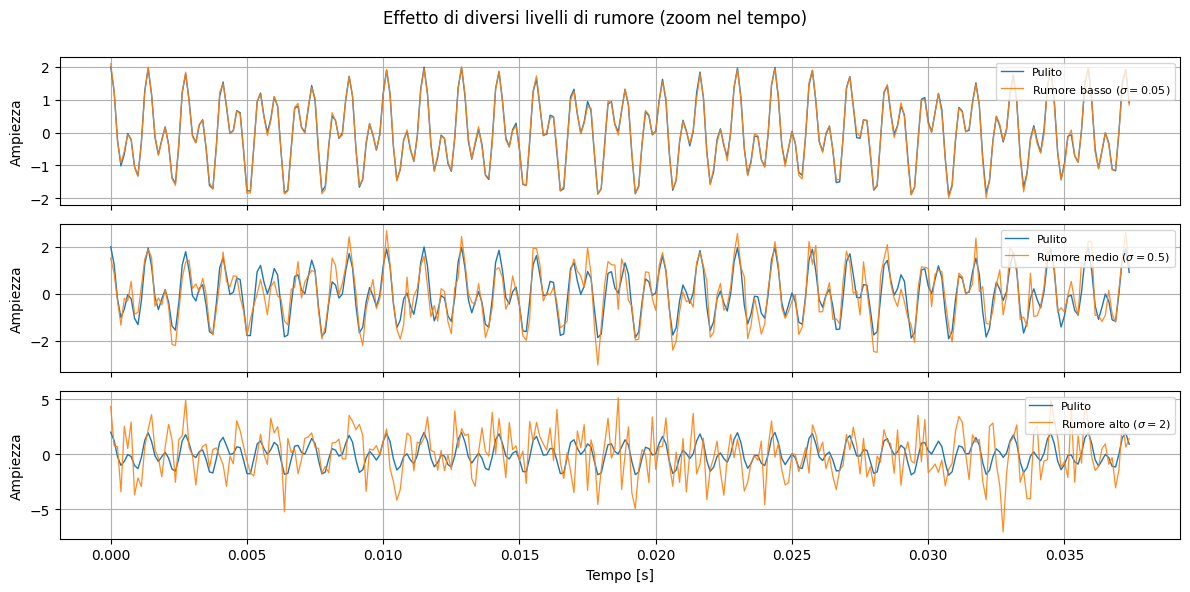

In [26]:
noise_dir = "Plots_noise"
os.makedirs(noise_dir, exist_ok=True)

# Finestra di zoom
N_zoom = 300
t_zoom = t_clean[:N_zoom]
x_clean_zoom = x_clean[:N_zoom]

# Rumore basso, medio, alto
sigmas_zoom = [0.05, 0.5, 2.0]
labels_zoom = [r"Rumore basso ($\sigma = 0.05$)",
               r"Rumore medio ($\sigma = 0.5$)",
               r"Rumore alto ($\sigma = 2$)"]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, sigma, lab in zip(axes, sigmas_zoom, labels_zoom):
    noise_zoom = np.random.normal(0, sigma, N_zoom)
    x_noisy_zoom = x_clean_zoom + noise_zoom

    ax.plot(t_zoom, x_clean_zoom, label="Pulito", linewidth=1.0)
    ax.plot(t_zoom, x_noisy_zoom, label=lab, linewidth=0.9, alpha=0.9)

    ax.set_ylabel("Ampiezza")
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Tempo [s]")
fig.suptitle("Effetto di diversi livelli di rumore (zoom nel tempo)", y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

save_plot_subfolder(noise_dir, "sovrapposizione_rumori.png")
plt.show()
plt.close()

σ = 0: accuratezza = 100.0%
σ = 0.05: accuratezza = 100.0%
σ = 0.2: accuratezza = 100.0%
σ = 0.5: accuratezza = 100.0%
σ = 1: accuratezza = 100.0%
σ = 2: accuratezza = 100.0%
Plot salvato in: Plots_noise/accuratezza_vs_sigma.png


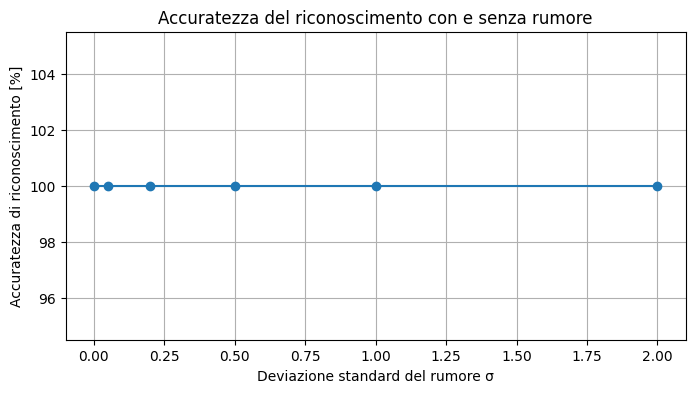

In [ ]:
noise_dir = "Plots_noise"
os.makedirs(noise_dir, exist_ok=True)

Fs = 8000
duration = 0.15
sequenza = "3456318060"

# Segnale pulito
x_clean = dialNumber(sequenza, Fs, duration)
true_seq = list(sequenza)

# Livelli di rumore (σ = 0 → caso senza rumore)
sigmas = [0, 0.05, 0.2, 0.5, 1, 2]
trials = 50

accuracies = []

for sigma in sigmas:
    correct = 0

    for _ in range(trials):
        if sigma == 0:
            x_noisy = x_clean.copy()
        else:
            noise = np.random.normal(0, sigma, len(x_clean))
            x_noisy = x_clean + noise

        detected = recSequence(x_noisy, duration, Fs)

        if detected == true_seq:
            correct += 1

    acc = 100 * correct / trials
    accuracies.append(acc)
    print(f"σ = {sigma}: accuratezza = {acc:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot(sigmas, accuracies, marker="o")
plt.xlabel("Deviazione standard del rumore σ")
plt.ylabel("Accuratezza di riconoscimento [%]")
plt.title("Accuratezza del riconoscimento con e senza rumore")
plt.grid(True)

save_plot_subfolder(noise_dir, "accuratezza_vs_sigma.png")
plt.show()
plt.close()

σ = 0: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 0.05: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 0.2: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 0.5: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 1: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 2: accuratezza media = 100.0% (su 5000 sequenze rumorose)
σ = 3: accuratezza media = 93.2% (su 5000 sequenze rumorose)
σ = 4: accuratezza media = 58.6% (su 5000 sequenze rumorose)
σ = 5: accuratezza media = 22.4% (su 5000 sequenze rumorose)
σ = 6: accuratezza media = 6.5% (su 5000 sequenze rumorose)
Plot salvato in: Plots_noise/accuratezza_random_vs_sigma.png


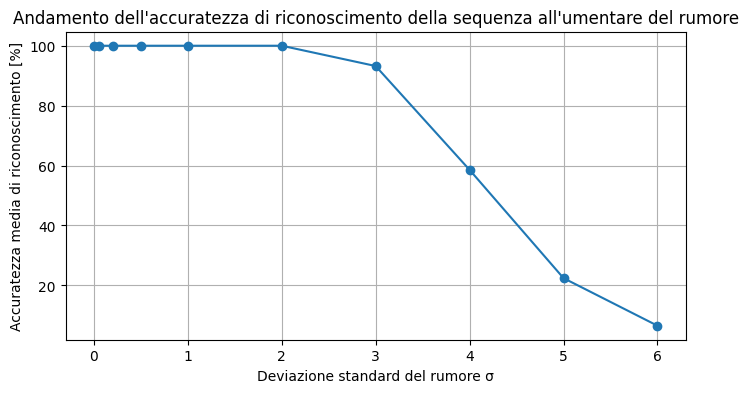

In [ ]:
noise_dir = "Plots_noise"
os.makedirs(noise_dir, exist_ok=True)

Fs = 8000
toneDuration = 0.15

# Alfabeto dei toni
alphabet = list(tones.keys())

def random_sequence(length, alphabet=alphabet):
    """Genera una sequenza casuale di tasti DTMF."""
    return "".join(np.random.choice(alphabet, size=length))

def recognition_accuracy_random_sequences(sigmas,
                                          Fs,
                                          toneDuration,
                                          seq_length=10,
                                          n_sequences=20,
                                          n_trials=5):
    """
    Calcola l'accuratezza media di riconoscimento su sequenze casuali
    per diversi livelli di rumore σ.

    sigmas        : lista di deviazioni standard del rumore
    seq_length    : lunghezza di ciascuna sequenza casuale
    n_sequences   : numero di sequenze casuali diverse per ciascun σ
    n_trials      : numero di realizzazioni rumorose per ciascuna sequenza
    """
    accuracies = []

    for sigma in sigmas:
        total = 0
        correct = 0

        for _ in range(n_sequences):
            seq = random_sequence(seq_length, alphabet)
            true_seq = list(seq)

            # segnale pulito per questa sequenza
            x_clean = dialNumber(seq, Fs, toneDuration)

            for _ in range(n_trials):
                if sigma == 0:
                    x_noisy = x_clean.copy()
                else:
                    noise = np.random.normal(0, sigma, len(x_clean))
                    x_noisy = x_clean + noise

                detected = recSequence(x_noisy, toneDuration, Fs)

                total += 1
                if detected == true_seq:
                    correct += 1

        acc = 100 * correct / total
        accuracies.append(acc)
        print(f"σ = {sigma}: accuratezza media = {acc:.1f}% "
              f"(su {total} sequenze rumorose)")

    return accuracies

# Esempio di utilizzo
sigmas = [0, 0.05, 0.2, 0.5, 1, 2, 3, 4, 5, 6]
np.random.seed(0)  # per riproducibilità

accuracies_rand = recognition_accuracy_random_sequences(
    sigmas=sigmas,
    Fs=Fs,
    toneDuration=toneDuration,
    seq_length=10,    # 10 toni per sequenza
    n_sequences=1000,   # 1000 sequenze diverse
    n_trials=5        # 5 realizzazioni di rumore per sequenza
)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(sigmas, accuracies_rand, marker="o")
plt.xlabel("Deviazione standard del rumore σ")
plt.ylabel("Accuratezza media di riconoscimento [%]")
plt.title("Andamento dell'accuratezza di riconoscimento della sequenza all'umentare del rumore")
plt.grid(True)

save_plot_subfolder(noise_dir, "accuratezza_random_vs_sigma.png")
plt.show()
plt.close()

### **3.2 Filtraggio segnale rumoroso**

Denoising

In [29]:
# Funzioni di denoising
def moving_average_denoise(x, M):
    """
    Denoising con media mobile di ordine M.
    Restituisce un segnale della stessa lunghezza di x.
    """
    kernel = np.ones(M) / M
    y = np.convolve(x, kernel, mode="same")
    return y


def leaky_integrator_denoise(x, lam):
    """
    Denoising con leaky integrator di primo ordine:
        y[n] = lam * y[n-1] + (1 - lam) * x[n]
    con 0 < lam < 1.
    """
    y = np.zeros_like(x)
    y[0] = (1 - lam) * x[0]
    for n in range(1, len(x)):
        y[n] = lam * y[n-1] + (1 - lam) * x[n]
    return y

In [ ]:
# Accuratezza con media mobile
def recognition_accuracy_random_sequences_ma(sigmas,
                                             Fs,
                                             toneDuration,
                                             seq_length=10,
                                             n_sequences=20,
                                             n_trials=5,
                                             M=5):
    """
    Come recognition_accuracy_random_sequences, ma applica
    un filtro a media mobile di ordine M prima del riconoscimento.
    """
    accuracies = []

    for sigma in sigmas:
        total = 0
        correct = 0

        for _ in range(n_sequences):
            seq = random_sequence(seq_length, alphabet)
            true_seq = list(seq)

            x_clean = dialNumber(seq, Fs, toneDuration)

            for _ in range(n_trials):
                if sigma == 0:
                    x_noisy = x_clean.copy()
                else:
                    noise = np.random.normal(0, sigma, len(x_clean))
                    x_noisy = x_clean + noise

                x_filt = moving_average_denoise(x_noisy, M)

                detected = recSequence(x_filt, toneDuration, Fs)

                total += 1
                if detected == true_seq:
                    correct += 1

        acc = 100 * correct / total
        accuracies.append(acc)
        print(f"σ = {sigma}: accuratezza media (media mobile M={M}) = {acc:.1f}% "
              f"(su {total} sequenze rumorose)")

    return accuracies

In [31]:
# Accuratezza con leaky integrator
def recognition_accuracy_random_sequences_leaky(sigmas,
                                                Fs,
                                                toneDuration,
                                                seq_length=10,
                                                n_sequences=20,
                                                n_trials=5,
                                                lam=0.8):
    """
    Come recognition_accuracy_random_sequences, ma applica
    un leaky integrator di primo ordine prima del riconoscimento.
    """
    accuracies = []

    for sigma in sigmas:
        total = 0
        correct = 0

        for _ in range(n_sequences):
            seq = random_sequence(seq_length, alphabet)
            true_seq = list(seq)

            x_clean = dialNumber(seq, Fs, toneDuration)

            for _ in range(n_trials):
                if sigma == 0:
                    x_noisy = x_clean.copy()
                else:
                    noise = np.random.normal(0, sigma, len(x_clean))
                    x_noisy = x_clean + noise

                x_filt = leaky_integrator_denoise(x_noisy, lam)

                detected = detect_sequence(x_filt, toneDuration, Fs)

                total += 1
                if detected == true_seq:
                    correct += 1

        acc = 100 * correct / total
        accuracies.append(acc)
        print(f"σ = {sigma}: accuratezza media (leaky λ={lam}) = {acc:.1f}% "
              f"(su {total} sequenze rumorose)")

    return accuracies

σ = 0: accuratezza media (media mobile M=5) = 100.0% (su 5000 sequenze rumorose)
σ = 0.05: accuratezza media (media mobile M=5) = 100.0% (su 5000 sequenze rumorose)
σ = 0.2: accuratezza media (media mobile M=5) = 100.0% (su 5000 sequenze rumorose)
σ = 0.5: accuratezza media (media mobile M=5) = 98.9% (su 5000 sequenze rumorose)
σ = 1: accuratezza media (media mobile M=5) = 49.7% (su 5000 sequenze rumorose)
σ = 2: accuratezza media (media mobile M=5) = 9.9% (su 5000 sequenze rumorose)
σ = 3: accuratezza media (media mobile M=5) = 3.0% (su 5000 sequenze rumorose)
σ = 4: accuratezza media (media mobile M=5) = 0.6% (su 5000 sequenze rumorose)
σ = 5: accuratezza media (media mobile M=5) = 0.1% (su 5000 sequenze rumorose)
σ = 6: accuratezza media (media mobile M=5) = 0.1% (su 5000 sequenze rumorose)
σ = 0: accuratezza media (leaky λ=0.8) = 100.0% (su 5000 sequenze rumorose)
σ = 0.05: accuratezza media (leaky λ=0.8) = 100.0% (su 5000 sequenze rumorose)
σ = 0.2: accuratezza media (leaky λ=0.8)

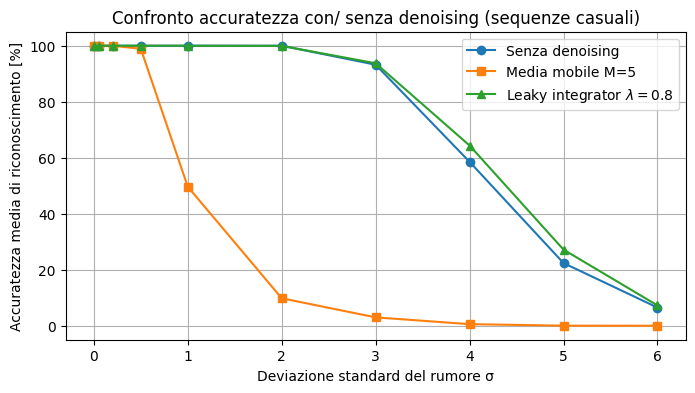

In [32]:
# Applicazione del denoising
sigmas = [0, 0.05, 0.2, 0.5, 1, 2, 3, 4, 5, 6]
np.random.seed(0)

M = 5        # ordine media mobile
lam = 0.8    # parametro leaky integrator

accuracies_ma = recognition_accuracy_random_sequences_ma(
    sigmas=sigmas,
    Fs=Fs,
    toneDuration=toneDuration,
    seq_length=10,
    n_sequences=1000,
    n_trials=5,
    M=M
)

accuracies_leaky = recognition_accuracy_random_sequences_leaky(
    sigmas=sigmas,
    Fs=Fs,
    toneDuration=toneDuration,
    seq_length=10,
    n_sequences=1000,
    n_trials=5,
    lam=lam
)

plt.figure(figsize=(8, 4))
plt.plot(sigmas, accuracies_rand, marker="o", label="Senza denoising")
plt.plot(sigmas, accuracies_ma, marker="s", label=f"Media mobile M={M}")
plt.plot(sigmas, accuracies_leaky, marker="^", label=fr"Leaky integrator $\lambda={lam}$")
plt.xlabel("Deviazione standard del rumore σ")
plt.ylabel("Accuratezza media di riconoscimento [%]")
plt.title("Confronto accuratezza con/ senza denoising (sequenze casuali)")
plt.grid(True)
plt.legend()

save_plot_subfolder(noise_dir, "accuratezza_random_vs_sigma_denoising.png")
plt.show()
plt.close()